# Four ConvLSTM forecasting methods (1982–2025)

This notebook loads the same cached tensor once, trains two ConvLSTM models, and produces four compared forecasts:

1. **Shreya** — predicts one month at a time using the 12 *observed* preceding months.
2. **Adapted Shreya** — predicts one month at a time, recursively feeding its own predictions back into the next 12-month input window.
3. **Iarla** — predicts 12 months in one shot, using the 12 *observed* months before each calendar-year block.
4. **Adapted Iarla** — predicts 12 months in one shot, recursively using its previous predicted 12-month block.

The forecast period is January 1982 through December 2025. The plots show the spatial box mean of `PRIMARY_FEATURE` (SST in this case), first monthly and then as annual averages. As the current tensor ends before 2025, the actual series and metrics stop at the final observed month. Observed input methods then continue recursively so that all four forecast lines still reach 2025.

## Note:

- **Starting point:** both recursive methods begin with the identical observed January–December 1981 input window.
- **Observed input methods:** Shreya uses rolling observed inputs and Iarla uses the observed previous calendar year while those observations exist. As the tensor ends before 2025, each continues recursively from that point (this is just a temporary fix).
- **Recursive methods:** Adapted Shreya updates its window by one predicted month. Adapted Iarla replaces the entire input window with the predicted 12month block.

## 1. Imports and setup

In [1]:
from pathlib import Path
import json
import pickle
import random
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Input, ConvLSTM2D, BatchNormalization, Conv2D, Reshape, Permute
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore", category=RuntimeWarning)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Available GPUs: []


## 2. Configuration

In [2]:
CACHE_PATH = Path(
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed"
    r"\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc"
)
OUTPUT_DIR = CACHE_PATH.parent / "ConvLSTM_four_method_1982_2025"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOOKBACK = 12
HORIZON = 12
VALIDATION_START = pd.Timestamp("1977-01-01")
FORECAST_START = pd.Timestamp("1982-01-01")
FORECAST_END = pd.Timestamp("2025-12-01")
PRIMARY_FEATURE = "salinity"

EPOCHS = 50
ONE_STEP_BATCH_SIZE = 4
ONE_SHOT_BATCH_SIZE = 2
LEARNING_RATE = 1e-3
TRAIN_MODELS = True

ONE_STEP_MODEL_PATH = OUTPUT_DIR / "best_one_step_convlstm.keras"
ONE_SHOT_MODEL_PATH = OUTPUT_DIR / "best_one_shot_12month_convlstm.keras"
SCALER_PATH = OUTPUT_DIR / "shared_training_only_scaler.pkl"
HISTORY_PATH = OUTPUT_DIR / "training_histories.json"
PREDICTIONS_PATH = OUTPUT_DIR / "four_method_predictions.nc"
METRICS_PATH = OUTPUT_DIR / "four_method_metrics.csv"

print("Tensor:", CACHE_PATH)
print("Outputs:", OUTPUT_DIR)

Tensor: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc
Outputs: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_four_method_1982_2025


## 3. Load the cached tensor

In [3]:
if not CACHE_PATH.exists():
    raise FileNotFoundError(f"Cached tensor not found:\n{CACHE_PATH}\nUpdate CACHE_PATH in the configuration cell.")

with xr.open_dataset(CACHE_PATH, engine="h5netcdf") as ds:
    if "climate" in ds.data_vars:
        combined_monthly = ds["climate"].load()
    elif len(ds.data_vars) == 1:
        combined_monthly = ds[next(iter(ds.data_vars))].load()
    else:
        raise ValueError(f"Could not identify tensor variable: {list(ds.data_vars)}")

combined_monthly = (
    combined_monthly.sortby("time")
    .transpose("time", "feature", "lat", "lon")
    .where(np.abs(combined_monthly) < 1e10)
    .astype(np.float32)
)

times = pd.DatetimeIndex(pd.to_datetime(combined_monthly.time.values))
candidate_features = combined_monthly.feature.values.astype(str).tolist()
train_reference_mask = times < VALIDATION_START
retained_features, quality_rows = [], []

for name in candidate_features:
    values = combined_monthly.sel(feature=name).values
    train_std = float(np.nanstd(values[train_reference_mask]))
    finite_fraction = float(np.isfinite(values).mean())
    quality_rows.append({"feature": name, "finite_fraction": finite_fraction, "training_std": train_std})
    if finite_fraction > 0 and np.isfinite(train_std) and train_std > 1e-8:
        retained_features.append(name)

display(pd.DataFrame(quality_rows))
removed = [name for name in candidate_features if name not in retained_features]
print("Removed empty/constant features:", removed)

combined_monthly = combined_monthly.sel(feature=retained_features)
features = retained_features
times = pd.DatetimeIndex(pd.to_datetime(combined_monthly.time.values))
lats, lons = combined_monthly.lat.values, combined_monthly.lon.values
raw_data = combined_monthly.transpose("time", "lat", "lon", "feature").values.astype(np.float32)

expected = pd.date_range(times.min(), times.max(), freq="MS")
missing_months = expected.difference(times)
if len(missing_months):
    print(f"Warning: tensor has {len(missing_months)} missing complete month(s):")
    print([timestamp.strftime("%Y-%m") for timestamp in missing_months])
    print("Training/validation samples crossing these gaps will be skipped.")
if PRIMARY_FEATURE not in features:
    raise ValueError(f"{PRIMARY_FEATURE!r} not found in retained features: {features}")
if times.min() > FORECAST_START - pd.DateOffset(months=LOOKBACK):
    raise ValueError("Tensor does not contain the 12 observed months needed to initialize the forecasts.")

ACTUAL_END = min(FORECAST_END, times.max())
if ACTUAL_END < FORECAST_START:
    raise ValueError("Tensor ends before the requested forecast period begins.")

required_forecast_months = pd.date_range(
    FORECAST_START - pd.DateOffset(months=LOOKBACK),
    ACTUAL_END,
    freq="MS",
)
missing_required_months = required_forecast_months.difference(times)
if len(missing_required_months):
    raise ValueError(
        "The tensor is missing month(s) required for the December 1981 initialization "
        "or observed comparison period: "
        + ", ".join(timestamp.strftime("%Y-%m") for timestamp in missing_required_months)
    )

print("Shape (time, lat, lon, feature):", raw_data.shape)
print("Features:", features)
print("Range:", times.min().strftime("%Y-%m"), "to", times.max().strftime("%Y-%m"))
print("Forecasts will run through:", FORECAST_END.strftime("%Y-%m"))
print("Actual comparison data end at:", ACTUAL_END.strftime("%Y-%m"))
if ACTUAL_END < FORECAST_END:
    print("After actual data end, observed-input methods continue recursively and the actual plot line is blank.")

,feature,finite_fraction,training_std
0,sst,1.0,4.128275
1,salinity,1.0,0.687953
2,thetao,1.0,3.708173
3,qnet,1.0,185.459488
4,u_current,1.0,0.082924
5,v_current,1.0,0.081375
6,era5_sst,1.0,4.137603
7,era5_u10,0.0,NaN
8,era5_v10,0.0,NaN
9,era5_runoff,1.0,0.000000


Removed empty/constant features: ['era5_u10', 'era5_v10', 'era5_runoff', 'era5_d2m', 'era5_skt', 'era5_stl2', 'era5_swvl1']
['1979-02']
Training/validation samples crossing these gaps will be skipped.
Shape (time, lat, lon, feature): (731, 41, 41, 7)
Features: ['sst', 'salinity', 'thetao', 'qnet', 'u_current', 'v_current', 'era5_sst']
Range: 1958-01 to 2018-12
Forecasts will run through: 2025-12
Actual comparison data end at: 2018-12
After actual data end, observed-input methods continue recursively and the actual plot line is blank.


## 4. Training set imputation/scaling

In [4]:
train_fit_mask = times < VALIDATION_START
n_time, n_lat, n_lon, n_features = raw_data.shape
training_reference = raw_data[train_fit_mask]
training_times = times[train_fit_mask]

month_climatology = np.full((12, n_lat, n_lon, n_features), np.nan, dtype=np.float32)
for month in range(1, 13):
    month_climatology[month - 1] = np.nanmean(training_reference[training_times.month == month], axis=0)

cell_mean = np.nanmean(training_reference, axis=0)
feature_median = np.array([np.nanmedian(training_reference[..., i]) for i in range(n_features)], dtype=np.float32)

data_filled = raw_data.copy()
for i, timestamp in enumerate(times):
    missing = ~np.isfinite(data_filled[i])
    if missing.any():
        data_filled[i][missing] = month_climatology[timestamp.month - 1][missing]
    missing = ~np.isfinite(data_filled[i])
    if missing.any():
        data_filled[i][missing] = cell_mean[missing]
    missing = ~np.isfinite(data_filled[i])
    if missing.any():
        fallback = np.broadcast_to(feature_median, data_filled[i].shape)
        data_filled[i][missing] = fallback[missing]

if not np.isfinite(data_filled).all():
    raise ValueError("Non-finite values remain after imputation.")

feature_mean = data_filled[train_fit_mask].mean(axis=(0, 1, 2)).astype(np.float32)
feature_std = data_filled[train_fit_mask].std(axis=(0, 1, 2)).astype(np.float32)
feature_std = np.where(feature_std < 1e-8, 1.0, feature_std).astype(np.float32)
data_scaled = ((data_filled - feature_mean) / feature_std).astype(np.float32)

def inverse_scale(values):
    return values * feature_std + feature_mean

with open(SCALER_PATH, "wb") as handle:
    pickle.dump({"features": features, "mean": feature_mean, "std": feature_std,
                 "month_climatology": month_climatology, "cell_mean": cell_mean,
                 "feature_median": feature_median, "fit_end": str(times[train_fit_mask][-1])}, handle)

display(pd.DataFrame({"feature": features, "training_mean": feature_mean, "training_std": feature_std}))

,feature,training_mean,training_std
0,sst,20.633944,4.128009
1,salinity,36.409763,0.688068
2,thetao,19.737841,3.707966
3,qnet,-28.248745,185.448532
4,u_current,0.023949,0.082915
5,v_current,-0.005960,0.081360
6,era5_sst,20.586727,4.137372


## 5. Building one step and 12-12 training samples

In [5]:
def is_consecutive(months):
    months = pd.DatetimeIndex(months)
    return months.equals(pd.date_range(months[0], periods=len(months), freq="MS"))

def make_one_step_samples(values, value_times):
    X, y, targets = [], [], []
    for target_i in range(LOOKBACK, len(value_times)):
        window_times = value_times[target_i - LOOKBACK:target_i + 1]
        if is_consecutive(window_times):
            X.append(values[target_i - LOOKBACK:target_i])
            y.append(values[target_i])
            targets.append(value_times[target_i])
    return np.asarray(X, np.float32), np.asarray(y, np.float32), pd.DatetimeIndex(targets)

def make_one_shot_samples(values, value_times):
    X, y, starts, ends = [], [], [], []
    required = LOOKBACK + HORIZON
    for start_i in range(len(value_times) - required + 1):
        block_times = value_times[start_i:start_i + required]
        if is_consecutive(block_times):
            split = start_i + LOOKBACK
            X.append(values[start_i:split])
            y.append(values[split:split + HORIZON])
            starts.append(value_times[split])
            ends.append(value_times[split + HORIZON - 1])
    return (np.asarray(X, np.float32), np.asarray(y, np.float32),
            pd.DatetimeIndex(starts), pd.DatetimeIndex(ends))

X1, y1, target1 = make_one_step_samples(data_scaled, times)
train1, val1 = target1 < VALIDATION_START, (target1 >= VALIDATION_START) & (target1 < FORECAST_START)

X12, y12, start12, end12 = make_one_shot_samples(data_scaled, times)
train12 = end12 < VALIDATION_START
val12 = (start12 >= VALIDATION_START) & (end12 < FORECAST_START)

if min(train1.sum(), val1.sum(), train12.sum(), val12.sum()) == 0:
    raise ValueError("A chronological training or validation split is empty.")

print("One-step train/validation:", X1[train1].shape, X1[val1].shape)
print("One-shot train/validation:", X12[train12].shape, X12[val12].shape)
print("Training targets end before:", VALIDATION_START.date())
print("Validation targets:", VALIDATION_START.date(), "to", (FORECAST_START - pd.DateOffset(months=1)).date())

One-step train/validation: (216, 12, 41, 41, 7) (47, 12, 41, 41, 7)
One-shot train/validation: (205, 12, 41, 41, 7) (25, 12, 41, 41, 7)
Training targets end before: 1977-01-01
Validation targets: 1977-01-01 to 1981-12-01


## 6. Defining the two ConvLSTM models

In [6]:
def build_one_step_model():
    model = Sequential([
        Input(shape=(LOOKBACK, n_lat, n_lon, n_features)),
        ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True), BatchNormalization(),
        ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True), BatchNormalization(),
        ConvLSTM2D(16, (3, 3), padding="same", return_sequences=False), BatchNormalization(),
        Conv2D(n_features, (3, 3), padding="same", activation="linear"),
    ], name="Shreya_one_step_ConvLSTM")
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss="mse", metrics=["mae"])
    return model

def build_one_shot_model():
    inputs = Input(shape=(LOOKBACK, n_lat, n_lon, n_features), name="preceding_12_months")
    x = ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = ConvLSTM2D(16, (3, 3), padding="same", return_sequences=False)(x)
    x = BatchNormalization()(x)
    x = Conv2D(HORIZON * n_features, (1, 1), padding="same", activation="linear")(x)
    x = Reshape((n_lat, n_lon, HORIZON, n_features))(x)
    outputs = Permute((3, 1, 2, 4), name="forecast_12_months")(x)
    model = Model(inputs, outputs, name="Iarla_one_shot_ConvLSTM")
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss="mse", metrics=["mae"])
    return model

one_step_model = build_one_step_model()
one_shot_model = build_one_shot_model()
one_step_model.summary()
one_shot_model.summary()

Model: "Shreya_one_step_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 12, 41, 41, 32)      │          45,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 41, 41, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 12, 41, 41, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 41, 41, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)           │ (None, 41, 41, 16)          │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 41, 41, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 41, 41, 7)           │           1,015 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 147,959 (577.96 KB)

 Trainable params: 147,799 (577.34 KB)

 Non-trainable params: 160 (640.00 B)

Model: "Iarla_one_shot_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ preceding_12_months (InputLayer)     │ (None, 12, 41, 41, 7)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)           │ (None, 12, 41, 41, 32)      │          45,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 12, 41, 41, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_4 (ConvLSTM2D)           │ (None, 12, 41, 41, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 41, 41, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_5 (ConvLSTM2D)           │ (None, 41, 41, 16)          │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 41, 41, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 41, 41, 84)          │           1,428 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 41, 41, 12, 7)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ forecast_12_months (Permute)         │ (None, 12, 41, 41, 7)       │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 148,372 (579.58 KB)

 Trainable params: 148,212 (578.95 KB)

 Non-trainable params: 160 (640.00 B)

## 7. Training/loading the models

In [7]:
def callbacks_for(path):
    return [
        ModelCheckpoint(path, monitor="val_loss", save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ]

if TRAIN_MODELS:
    h1 = one_step_model.fit(
        X1[train1], y1[train1], validation_data=(X1[val1], y1[val1]),
        epochs=EPOCHS, batch_size=ONE_STEP_BATCH_SIZE, shuffle=False,
        callbacks=callbacks_for(ONE_STEP_MODEL_PATH), verbose=1,
    )
    h12 = one_shot_model.fit(
        X12[train12], y12[train12], validation_data=(X12[val12], y12[val12]),
        epochs=EPOCHS, batch_size=ONE_SHOT_BATCH_SIZE, shuffle=False,
        callbacks=callbacks_for(ONE_SHOT_MODEL_PATH), verbose=1,
    )
    histories = {
        "one_step": {k: [float(x) for x in v] for k, v in h1.history.items()},
        "one_shot": {k: [float(x) for x in v] for k, v in h12.history.items()},
    }
    HISTORY_PATH.write_text(json.dumps(histories, indent=2))
else:
    for path in (ONE_STEP_MODEL_PATH, ONE_SHOT_MODEL_PATH):
        if not path.exists():
            raise FileNotFoundError(f"TRAIN_MODELS=False but model does not exist: {path}")

one_step_model = tf.keras.models.load_model(ONE_STEP_MODEL_PATH)
one_shot_model = tf.keras.models.load_model(ONE_SHOT_MODEL_PATH)
print("Loaded best validation models.")

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - loss: 1.0416 - mae: 0.7050
Epoch 1: val_loss improved from None to 0.70599, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_four_method_1982_2025\best_one_step_convlstm.keras

Epoch 1: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_four_method_1982_2025\best_one_step_convlstm.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 906ms/step - loss: 0.6815 - mae: 0.5638 - val_loss: 0.7060 - val_mae: 0.5605 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - loss: 0.4520 - mae: 0.4630
Epoch 2: val_loss improved from 0.70599 to 0.66053, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_four_method_1982_2025\best_one_step_convlstm.keras

Epoch 2: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_four_method_1982_2025\best_one_step_convlstm.keras
54/54 ━━━━━━━━━━━━━━━━━

## 8. Generate all four forecasts

The adapted methods are started with the same 12 observed months ending December 1981, after which only their own predictions enter their input windows.

In [19]:
forecast_times = pd.date_range(FORECAST_START, FORECAST_END, freq="MS")
time_to_index = {timestamp: i for i, timestamp in enumerate(times)}

def observed_window_before(target_time):
    target_i = time_to_index[target_time]
    window = data_scaled[target_i - LOOKBACK:target_i]
    window_times = times[target_i - LOOKBACK:target_i]
    if len(window) != LOOKBACK or not is_consecutive(window_times):
        raise ValueError(f"Invalid observed input window before {target_time:%Y-%m}")
    return window.copy()

# Shreya
shreya_scaled = np.empty((len(forecast_times), n_lat, n_lon, n_features), np.float32)
shreya_window = observed_window_before(FORECAST_START)
for i, target_time in enumerate(forecast_times):
    preceding = pd.date_range(target_time - pd.DateOffset(months=LOOKBACK), periods=LOOKBACK, freq="MS")
    if all(timestamp in time_to_index for timestamp in preceding):
        shreya_window = np.stack([data_scaled[time_to_index[timestamp]] for timestamp in preceding])
    prediction = one_step_model.predict(shreya_window[None, ...], verbose=0)[0]
    shreya_scaled[i] = prediction
    shreya_window = np.concatenate([shreya_window[1:], prediction[None, ...]], axis=0)

# Adapted Shreya
adapted_shreya_scaled = np.empty_like(shreya_scaled)
recursive_window = observed_window_before(FORECAST_START)
for i in range(len(forecast_times)):
    prediction = one_step_model.predict(recursive_window[None, ...], verbose=0)[0]
    adapted_shreya_scaled[i] = prediction
    recursive_window = np.concatenate([recursive_window[1:], prediction[None, ...]], axis=0)

# Calendar year starts for 12month blocks
block_starts = pd.date_range(FORECAST_START, FORECAST_END, freq="YS")
if len(forecast_times) % HORIZON:
    raise ValueError("Forecast period must contain a whole number of 12-month blocks.")

# Iarla
iarla_blocks = []
iarla_input = observed_window_before(FORECAST_START)
for block_start in block_starts:
    preceding = pd.date_range(block_start - pd.DateOffset(months=LOOKBACK), periods=LOOKBACK, freq="MS")
    if all(timestamp in time_to_index for timestamp in preceding):
        iarla_input = np.stack([data_scaled[time_to_index[timestamp]] for timestamp in preceding])
    prediction_block = one_shot_model.predict(iarla_input[None, ...], verbose=0)[0]
    iarla_blocks.append(prediction_block)
    iarla_input = prediction_block.copy()
iarla_scaled = np.concatenate(iarla_blocks, axis=0)

# Adapted Iarla
adapted_iarla_blocks = []
recursive_block = observed_window_before(FORECAST_START)
for _ in block_starts:
    prediction_block = one_shot_model.predict(recursive_block[None, ...], verbose=0)[0]
    adapted_iarla_blocks.append(prediction_block)
    recursive_block = prediction_block.copy()
adapted_iarla_scaled = np.concatenate(adapted_iarla_blocks, axis=0)

truth_scaled = np.full((len(forecast_times), n_lat, n_lon, n_features), np.nan, np.float32)
for i, timestamp in enumerate(forecast_times):
    if timestamp in time_to_index:
        truth_scaled[i] = data_scaled[time_to_index[timestamp]]
truth = inverse_scale(truth_scaled)
predictions = {
    "Shreya (observed inputs)": inverse_scale(shreya_scaled),
    "Adapted Shreya (recursive)": inverse_scale(adapted_shreya_scaled),
    "Iarla (observed blocks)": inverse_scale(iarla_scaled),
    "Adapted Iarla (recursive blocks)": inverse_scale(adapted_iarla_scaled),
}

for name, values in predictions.items():
    assert values.shape == truth.shape, (name, values.shape, truth.shape)
    assert np.isfinite(values).all(), f"Non-finite predictions in {name}"

print("Forecast dates:", forecast_times[0], "to", forecast_times[-1])
print("Each result shape:", truth.shape)

Forecast dates: 1982-01-01 00:00:00 to 2025-12-01 00:00:00
Each result shape: (528, 41, 41, 7)


## 8.5. Change primary variable

In [66]:
PRIMARY_FEATURE = "salinity"

if PRIMARY_FEATURE not in features:
    raise ValueError(
        f"{PRIMARY_FEATURE!r} is unavailable. Choose from: {features}"
    )

print("Selected feature:", PRIMARY_FEATURE)

Selected feature: salinity


## 9. Direct monthly comparison

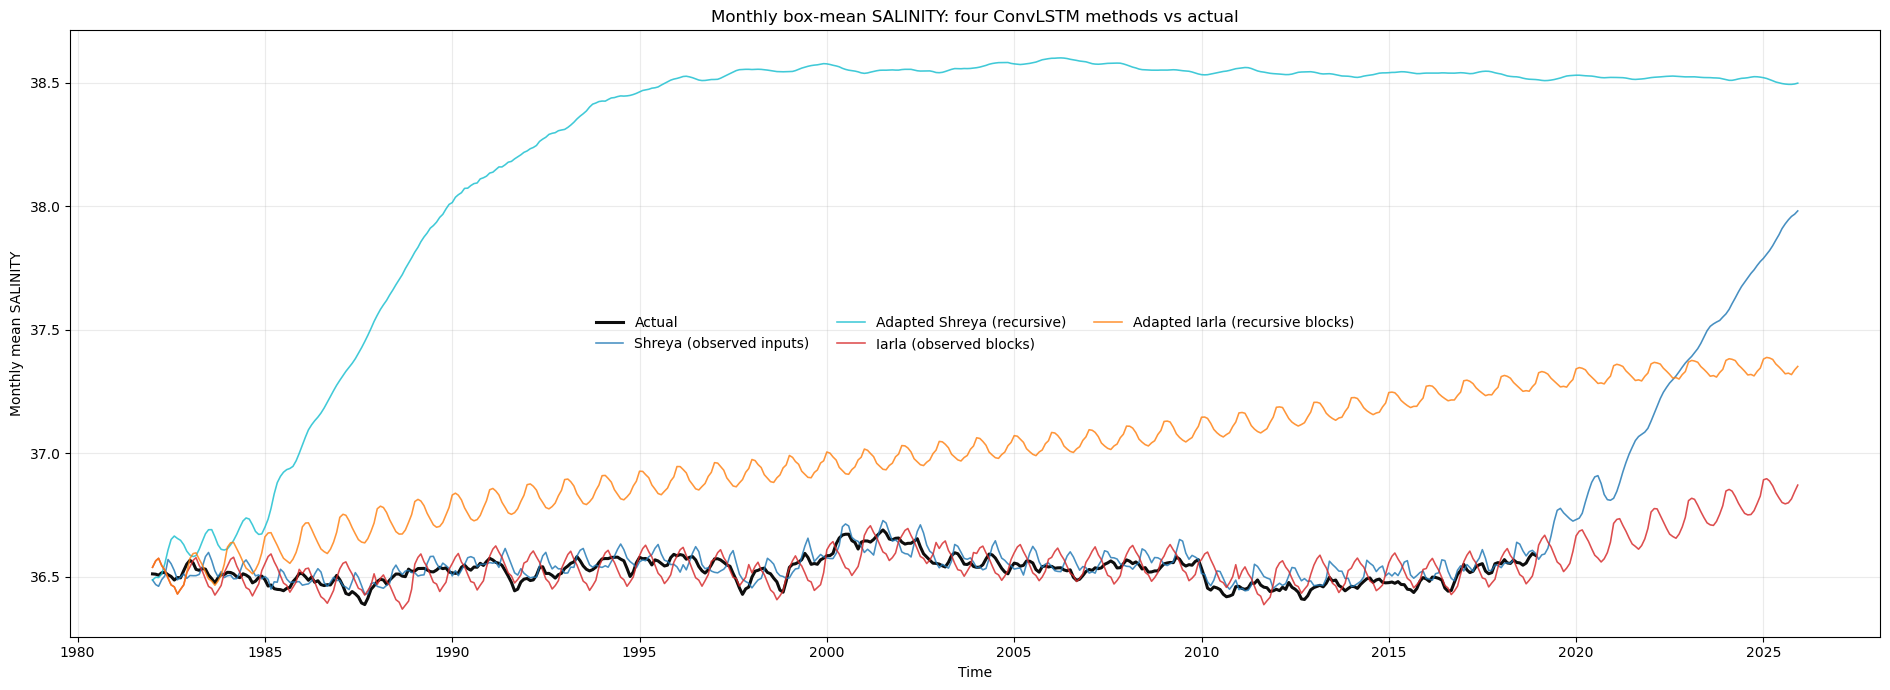

In [67]:
primary_index = features.index(PRIMARY_FEATURE)

def box_mean(values):
    return np.nanmean(values[..., primary_index], axis=(1, 2))

monthly_series = {"Actual": box_mean(truth)}
monthly_series.update({name: box_mean(values) for name, values in predictions.items()})
monthly_df = pd.DataFrame(monthly_series, index=forecast_times)
monthly_df.index.name = "time"

colors = {
    "Actual": "black",
    "Shreya (observed inputs)": "#1f77b4",
    "Adapted Shreya (recursive)": "#17becf",
    "Iarla (observed blocks)": "#d62728",
    "Adapted Iarla (recursive blocks)": "#ff7f0e",
}

fig, ax = plt.subplots(figsize=(19, 7))
for name in monthly_df.columns:
    ax.plot(monthly_df.index, monthly_df[name], label=name, color=colors[name],
            linewidth=2.2 if name == "Actual" else 1.15, alpha=0.95 if name == "Actual" else 0.82)
ax.set(title=f"Monthly box-mean {PRIMARY_FEATURE.upper()}: four ConvLSTM methods vs actual",
       xlabel="Time", ylabel=f"Monthly mean {PRIMARY_FEATURE.upper()}")
ax.grid(alpha=0.25)
ax.legend(ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "monthly_four_method_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Annual avg comparison

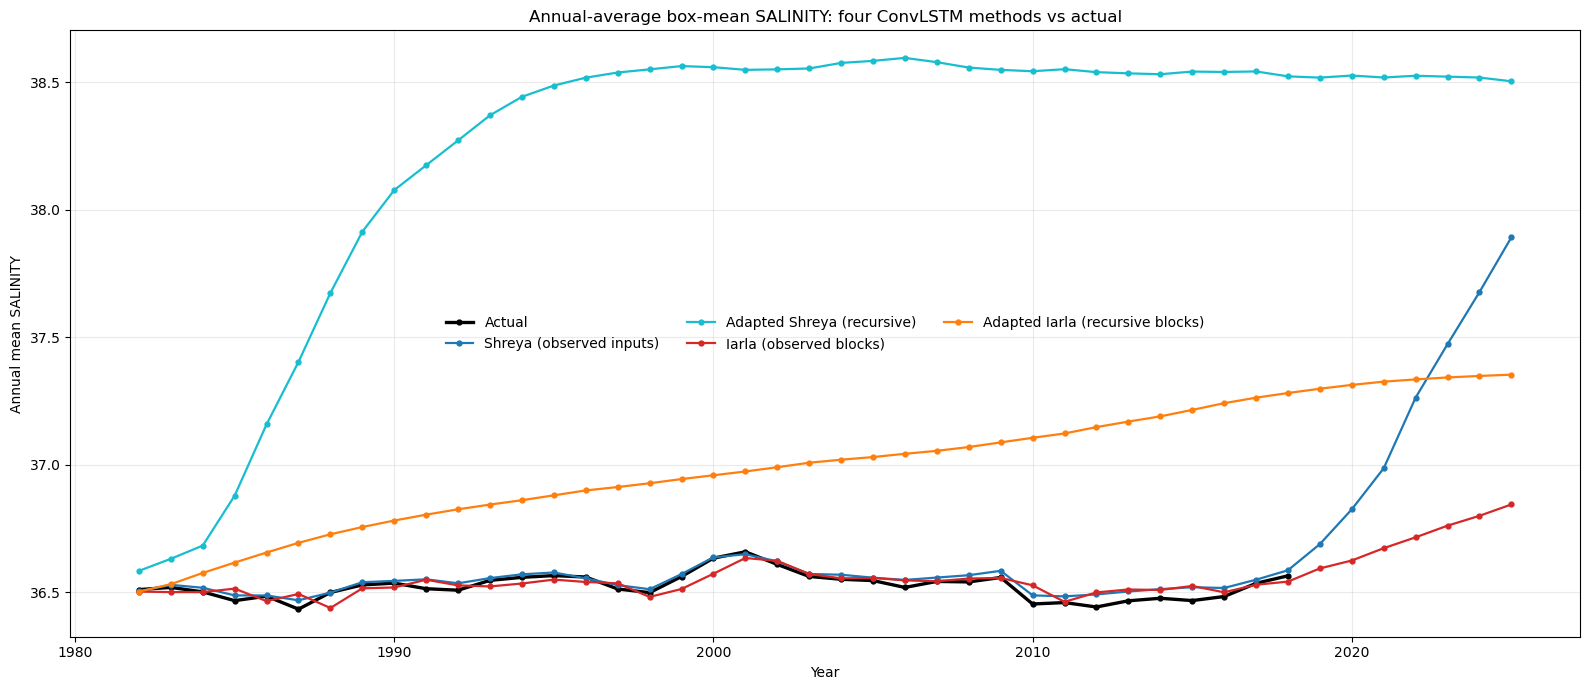

,Actual,Shreya (observed inputs),Adapted Shreya (recursive),Iarla (observed blocks),Adapted Iarla (recursive blocks)
time,,,,,
1982-01-01,36.510639,36.503971,36.583977,36.502827,36.502827
1983-01-01,36.519196,36.529224,36.631306,36.500805,36.531769
1984-01-01,36.501644,36.517792,36.683205,36.500790,36.575939
1985-01-01,36.467258,36.487850,36.878868,36.514454,36.616570
1986-01-01,36.484734,36.487591,37.158424,36.465481,36.656040
1987-01-01,36.433926,36.468674,37.403301,36.493412,36.693935
1988-01-01,36.499325,36.498852,37.673672,36.438580,36.727428
1989-01-01,36.528896,36.539486,37.913670,36.515614,36.755890
1990-01-01,36.535976,36.544716,38.076778,36.519035,36.781319


In [69]:
annual_df = monthly_df.resample("YS").mean()

fig, ax = plt.subplots(figsize=(16, 7))
for name in annual_df.columns:
    ax.plot(annual_df.index.year, annual_df[name], marker="o", markersize=3.5,
            label=name, color=colors[name], linewidth=2.4 if name == "Actual" else 1.6)
ax.set(title=f"Annual-average box-mean {PRIMARY_FEATURE.upper()}: four ConvLSTM methods vs actual",
       xlabel="Year", ylabel=f"Annual mean {PRIMARY_FEATURE.upper()}")
ax.grid(alpha=0.25)
ax.legend(ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "annual_four_method_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

display(annual_df)

## 11. Summary metrics and saved prediction data

In [70]:
metric_rows = []
actual_monthly = monthly_df["Actual"].to_numpy()
for name in predictions:
    predicted_monthly = monthly_df[name].to_numpy()
    monthly_valid = np.isfinite(actual_monthly) & np.isfinite(predicted_monthly)
    annual_actual = annual_df["Actual"].to_numpy()
    annual_predicted = annual_df[name].to_numpy()
    annual_valid = np.isfinite(annual_actual) & np.isfinite(annual_predicted)
    metric_rows.append({
        "method": name,
        "comparison_start": forecast_times[monthly_valid][0],
        "comparison_end": forecast_times[monthly_valid][-1],
        "monthly_MAE": mean_absolute_error(actual_monthly[monthly_valid], predicted_monthly[monthly_valid]),
        "monthly_RMSE": np.sqrt(mean_squared_error(actual_monthly[monthly_valid], predicted_monthly[monthly_valid])),
        "monthly_R2": r2_score(actual_monthly[monthly_valid], predicted_monthly[monthly_valid]),
        "annual_MAE": mean_absolute_error(annual_actual[annual_valid], annual_predicted[annual_valid]),
        "annual_RMSE": np.sqrt(mean_squared_error(annual_actual[annual_valid], annual_predicted[annual_valid])),
        "annual_R2": r2_score(annual_actual[annual_valid], annual_predicted[annual_valid]),
    })
metrics_df = pd.DataFrame(metric_rows).sort_values("monthly_RMSE")
display(metrics_df)
metrics_df.to_csv(METRICS_PATH, index=False)
monthly_df.to_csv(OUTPUT_DIR / "monthly_box_mean_comparison.csv")
annual_df.to_csv(OUTPUT_DIR / "annual_box_mean_comparison.csv")

safe_names = {
    "Shreya (observed inputs)": "shreya_observed_inputs",
    "Adapted Shreya (recursive)": "adapted_shreya_recursive",
    "Iarla (observed blocks)": "iarla_observed_blocks",
    "Adapted Iarla (recursive blocks)": "adapted_iarla_recursive_blocks",
}
data_vars = {"actual": (("time", "lat", "lon", "feature"), truth)}
for label, values in predictions.items():
    data_vars[safe_names[label]] = (("time", "lat", "lon", "feature"), values)

prediction_ds = xr.Dataset(
    data_vars=data_vars,
    coords={"time": forecast_times, "lat": lats, "lon": lons, "feature": features},
    attrs={
        "description": "Four ConvLSTM forecasts through December 2025; actual data are NaN after the tensor ends",
        "training_targets": "before 1977-01",
        "validation_targets": "1977-01 through 1981-12",
    },
)
prediction_ds.to_netcdf(PREDICTIONS_PATH, engine="h5netcdf")
print("Saved outputs to:", OUTPUT_DIR)
print("Prediction tensor:", PREDICTIONS_PATH)

,method,comparison_start,comparison_end,monthly_MAE,monthly_RMSE,monthly_R2,annual_MAE,annual_RMSE,annual_R2
0,Shreya (observed inputs),1982-01-01,2018-12-01,0.032400,0.040038,0.461964,0.019274,0.023139,0.783443
2,Iarla (observed blocks),1982-01-01,2018-12-01,0.045844,0.055278,-0.025593,0.025622,0.032327,0.577311
3,Adapted Iarla (recursive blocks),1982-01-01,2018-12-01,0.415890,0.466321,-71.985718,0.414765,0.464887,-86.413918
1,Adapted Shreya (recursive),1982-01-01,2018-12-01,1.676678,1.783392,-1066.483032,1.676447,1.782910,-1284.711792


Saved outputs to: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_four_method_1982_2025
Prediction tensor: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_four_method_1982_2025\four_method_predictions.nc


In [71]:
# Shared plotting function

def plot_method_full_range(
    method_name,
    prediction_color,
    file_prefix,
):
    # Actual monthly spatial box avg
    actual_full_monthly_values = np.nanmean(
        data_filled[..., primary_index],
        axis=(1, 2),
    )

    actual_full_monthly = pd.Series(
        actual_full_monthly_values,
        index=times,
        name="Actual SST",
    )

    # Predictions (January 1982 through December 2025)
    predicted_monthly = monthly_df[method_name].copy()

    # Annual averages
    actual_full_annual = actual_full_monthly.resample("YS").mean()
    predicted_annual = predicted_monthly.resample("YS").mean()

    actual_end = actual_full_monthly.dropna().index.max()
    forecast_end = predicted_monthly.dropna().index.max()

    # Monthly SST
    fig, ax = plt.subplots(figsize=(20, 7))

    ax.plot(
        actual_full_monthly.index,
        actual_full_monthly.values,
        color="#1f77b4",
        linewidth=1.5,
        label="Actual SST",
    )

    ax.plot(
        predicted_monthly.index,
        predicted_monthly.values,
        color=prediction_color,
        linewidth=1.7,
        linestyle="--",
        label=method_name,
    )


    ax.set_title(
        f"Monthly Box-Mean SST Across the Study Region — {method_name}"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Monthly box-mean SST (°C)")
    ax.set_xlim(
        actual_full_monthly.index.min(),
        pd.Timestamp("2025-12-31"),
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=3)
    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / f"{file_prefix}_monthly_full_range.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    # Annual SST
    fig, ax = plt.subplots(figsize=(17, 7))

    ax.plot(
        actual_full_annual.index.year,
        actual_full_annual.values,
        color="#1f77b4",
        marker="o",
        markersize=3,
        linewidth=2,
        label="Actual SST",
    )

    ax.plot(
        predicted_annual.index.year,
        predicted_annual.values,
        color=prediction_color,
        marker="s",
        markersize=4,
        linewidth=2,
        linestyle="--",
        label=method_name,
    )

    ax.set_title(
        f"Annual Mean SST Across the Study Region — {method_name}"
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual box-mean SST (°C)")
    ax.set_xlim(
        actual_full_annual.index.year.min() - 1,
        2026,
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=3)
    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / f"{file_prefix}_annual_full_range.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Actual data: {actual_full_monthly.index.min():%Y-%m} "
        f"to {actual_end:%Y-%m}"
    )
    print(
        f"{method_name}: {predicted_monthly.index.min():%Y-%m} "
        f"to {forecast_end:%Y-%m}"
    )

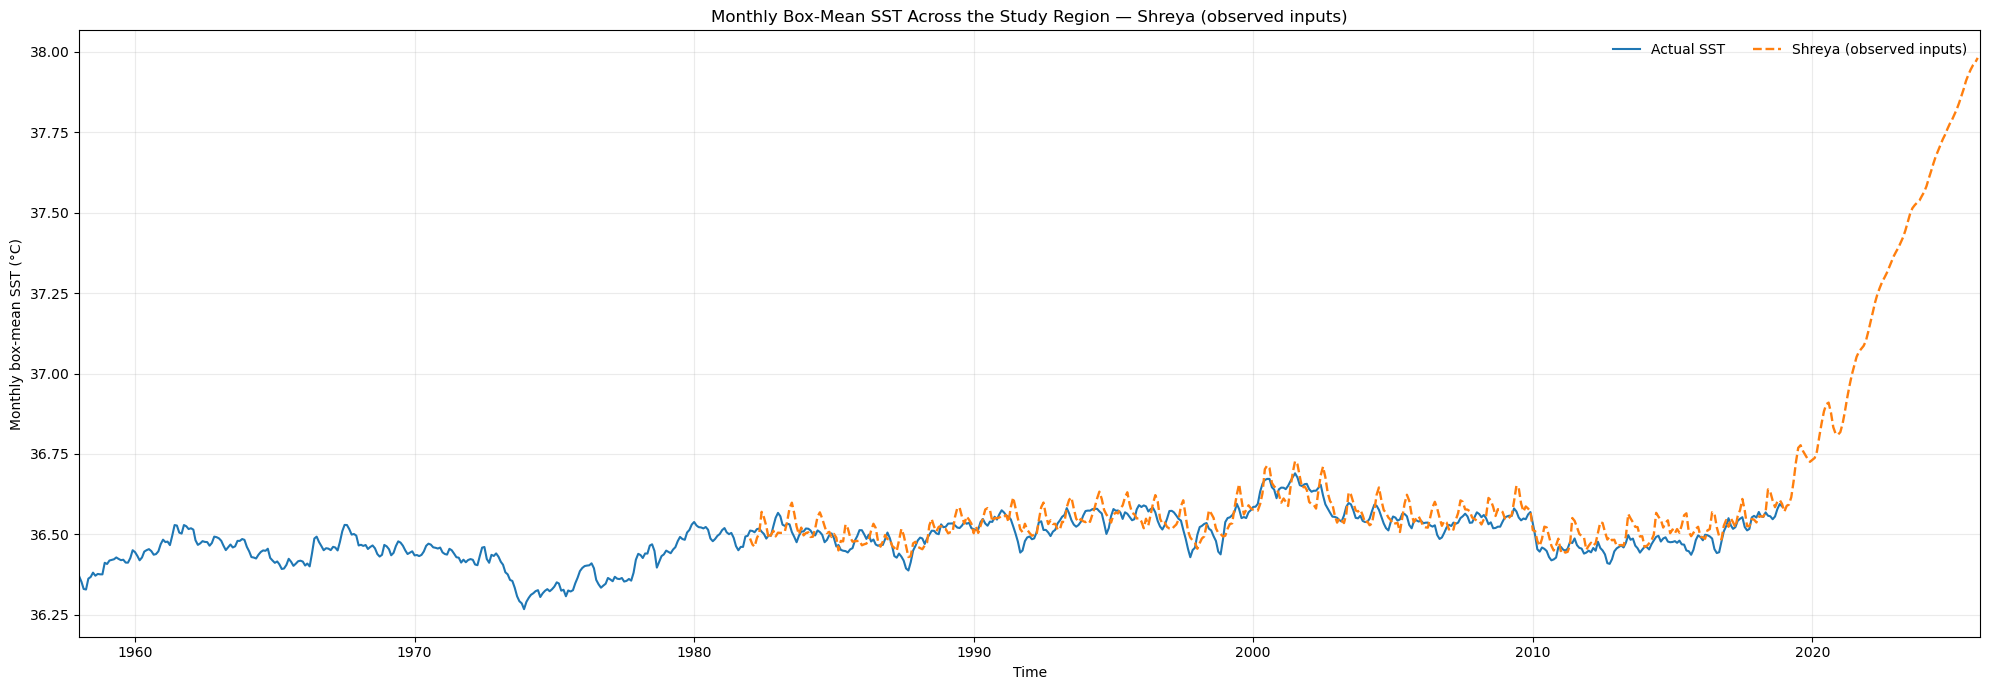

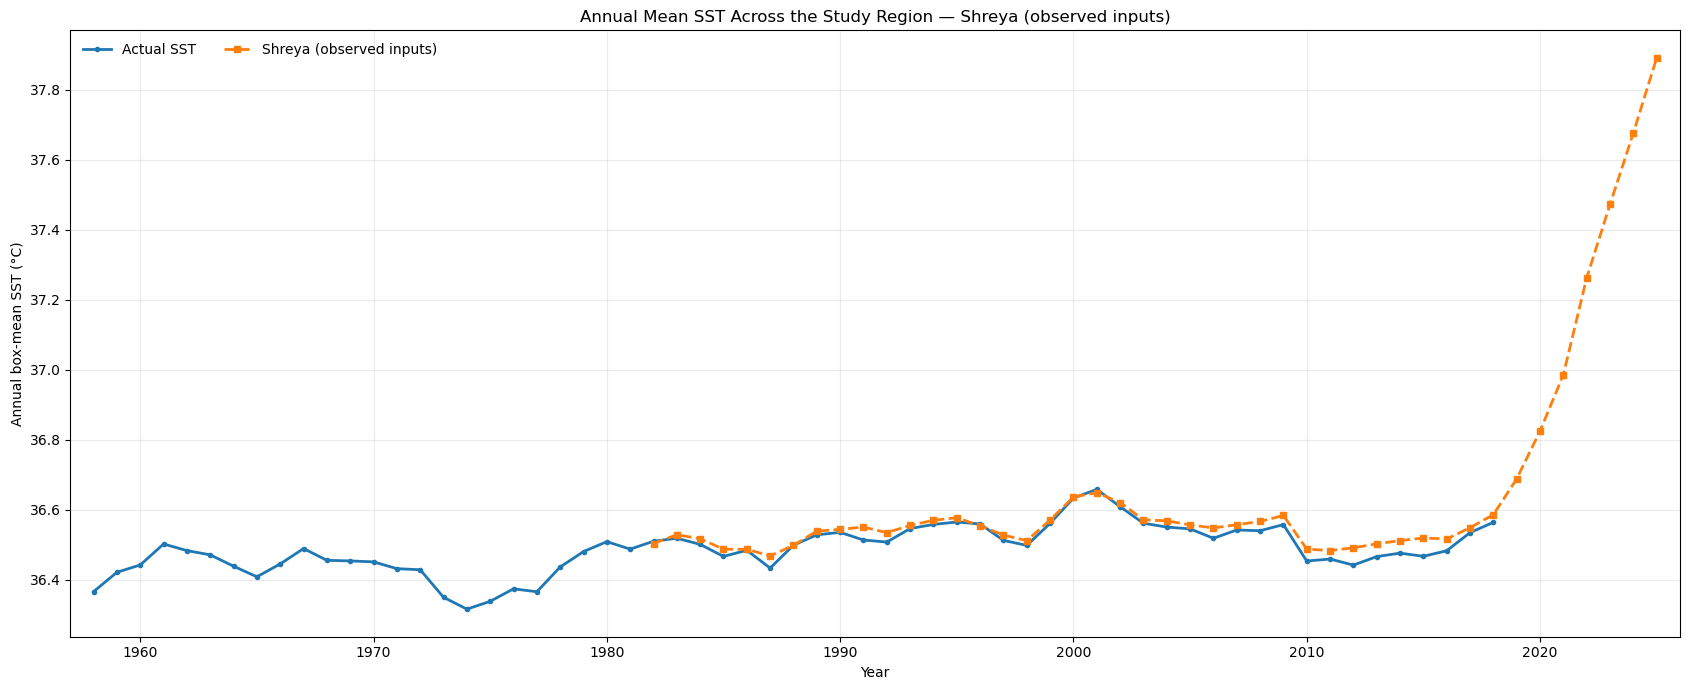

Actual data: 1958-01 to 2018-12
Shreya (observed inputs): 1982-01 to 2025-12


In [72]:
# Shreya method

plot_method_full_range(
    method_name="Shreya (observed inputs)",
    prediction_color="#ff7f0e",
    file_prefix="shreya_observed",
)

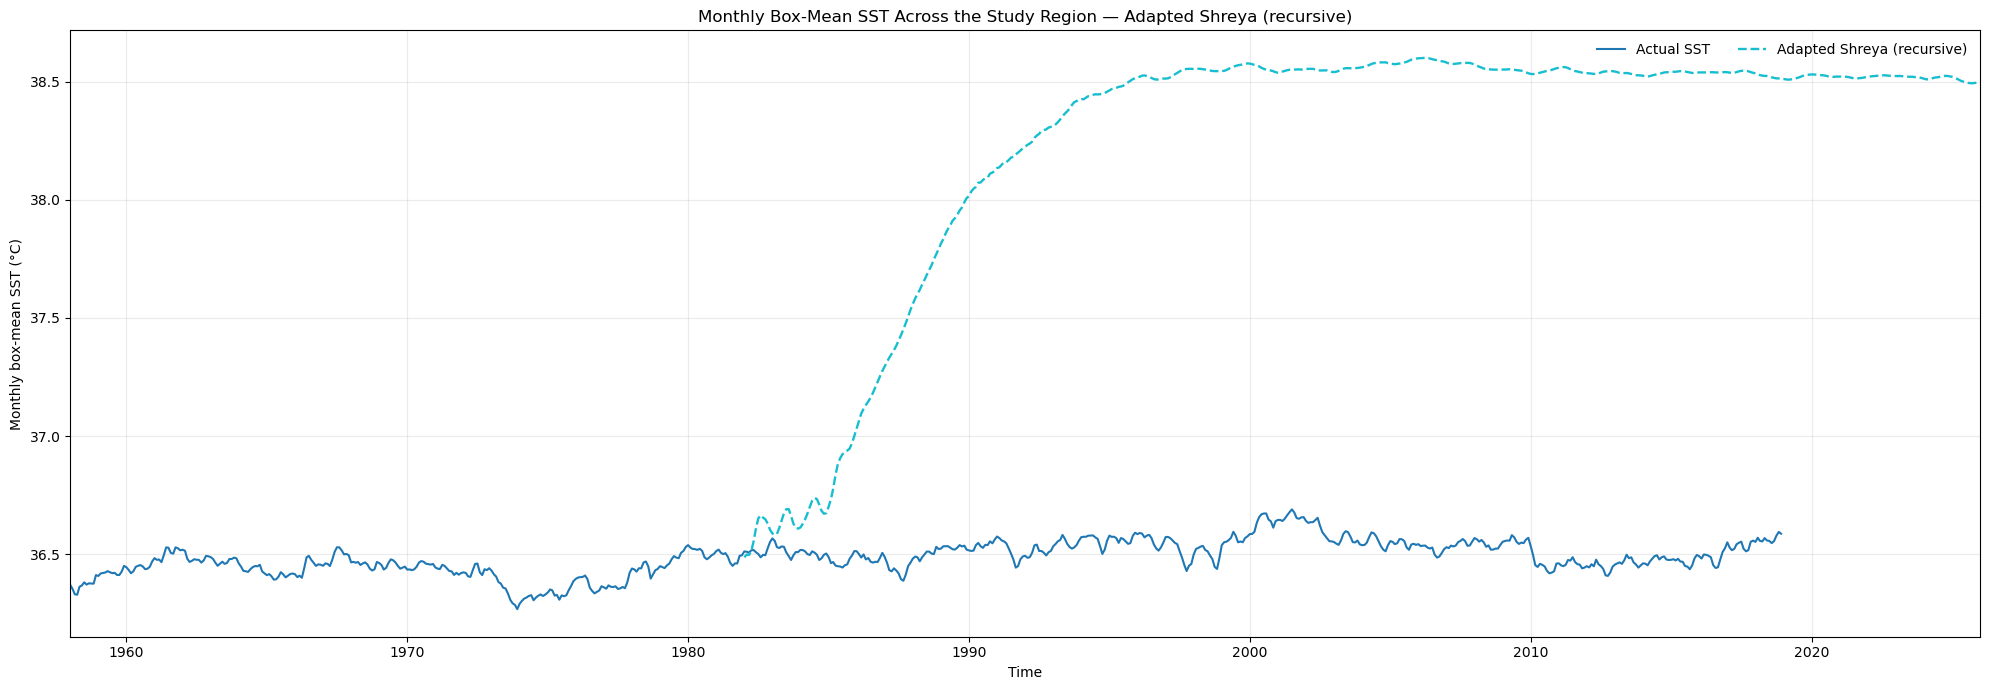

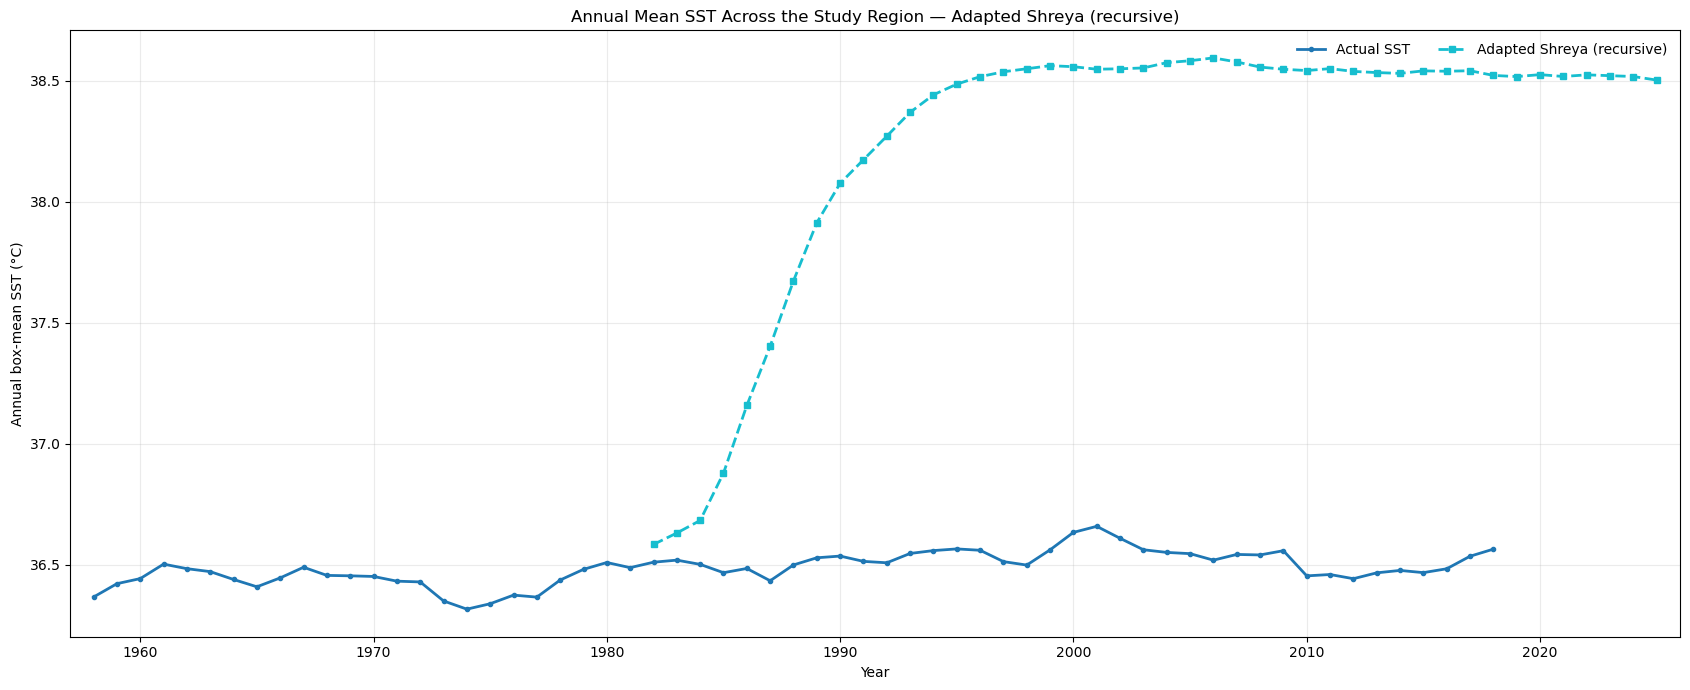

Actual data: 1958-01 to 2018-12
Adapted Shreya (recursive): 1982-01 to 2025-12


In [73]:
# Adapted Shreya

plot_method_full_range(
    method_name="Adapted Shreya (recursive)",
    prediction_color="#17becf",
    file_prefix="adapted_shreya_recursive",
)

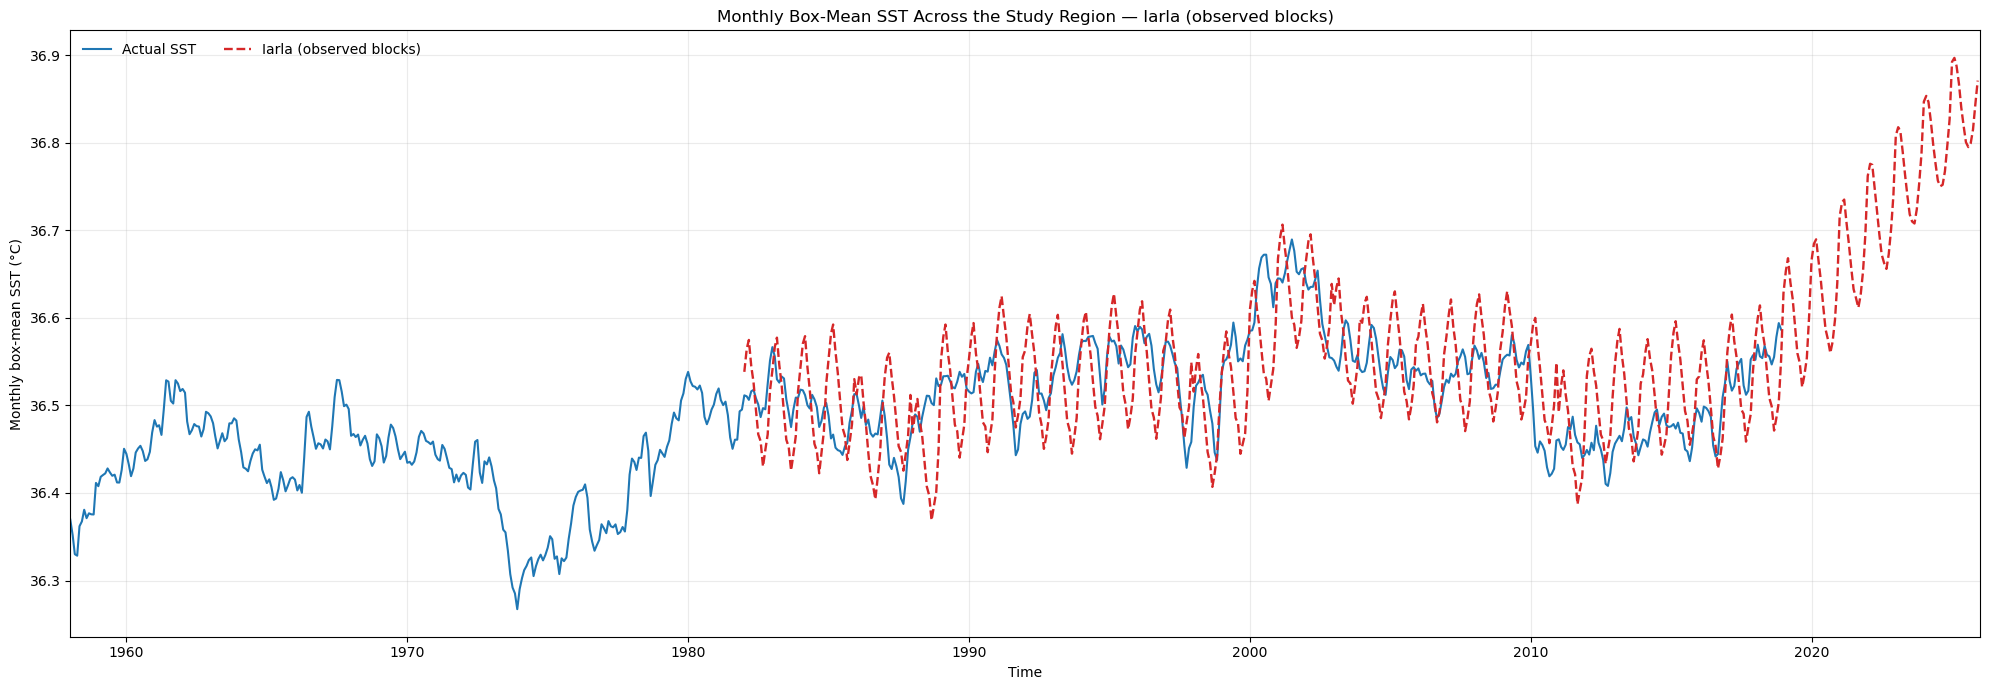

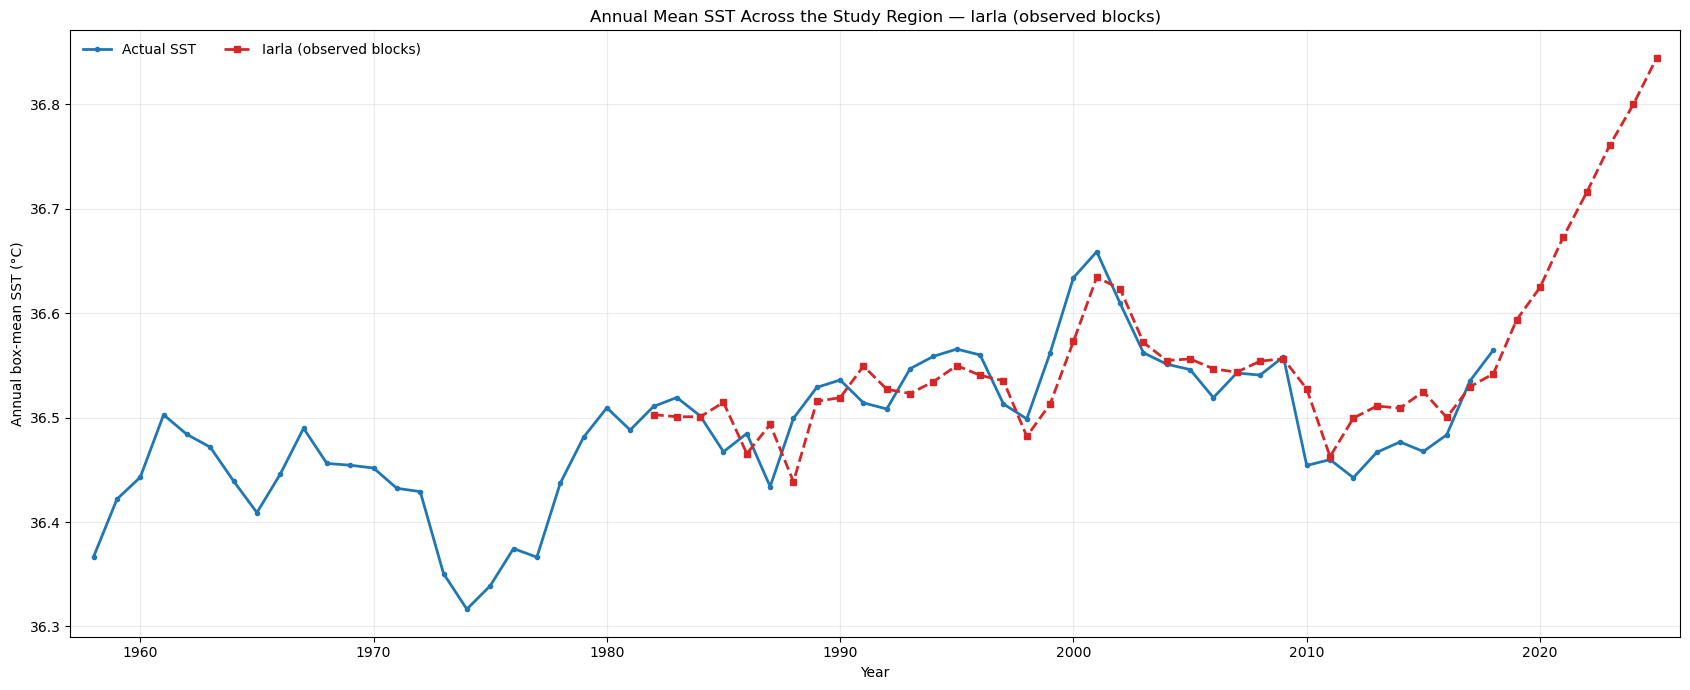

Actual data: 1958-01 to 2018-12
Iarla (observed blocks): 1982-01 to 2025-12


In [74]:
# Iarla method

plot_method_full_range(
    method_name="Iarla (observed blocks)",
    prediction_color="#d62728",
    file_prefix="iarla_observed",
)

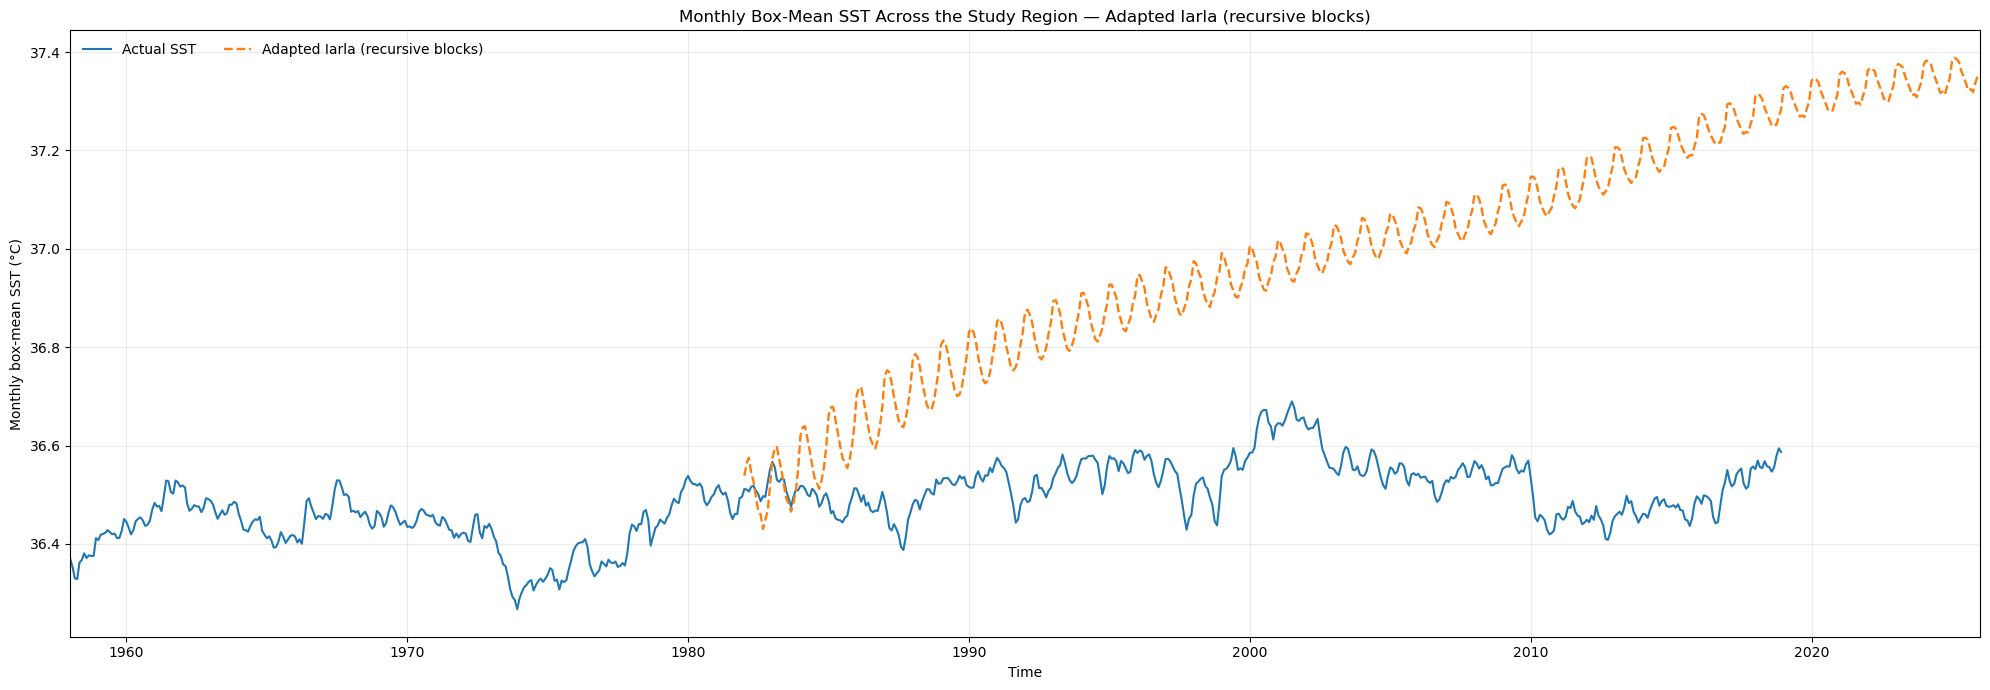

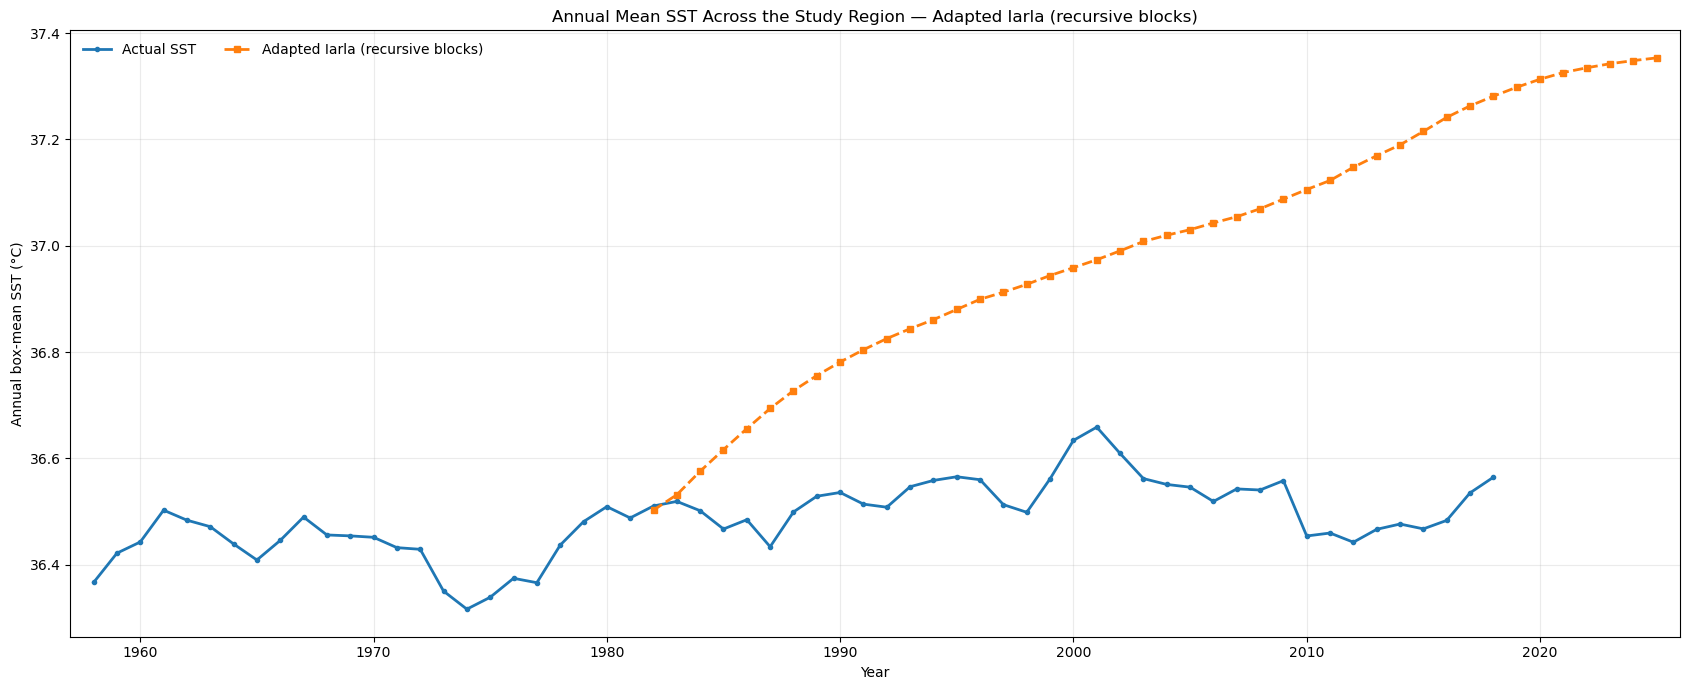

Actual data: 1958-01 to 2018-12
Adapted Iarla (recursive blocks): 1982-01 to 2025-12


In [75]:
# Adapted Iarla method

plot_method_full_range(
    method_name="Adapted Iarla (recursive blocks)",
    prediction_color="#ff7f0e",
    file_prefix="adapted_iarla_recursive",
)